# Validação da máscara de restrições

## Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import find_dotenv, load_dotenv
import os

## PATHS

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print(
        "Aviso: A variável GOOGLE_APPLICATION_CREDENTIALS não foi encontrada no arquivo .env"
    )
    print("O acesso ao GCS pode falhar.")

BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")

STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
MASK_PATH = f"gs://{BUCKET_NAME}/processed/mascara_exclusao_final.gpkg"
SUPER_LAYER_PATH = (
    f"gs://{BUCKET_NAME}/processed/restricoes_consolidadas_com_atributos.gpkg"
)

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Carga de Dados

In [3]:
states_gdf = gpd.read_file(STATES_PATH)
mascara_gdf = gpd.read_file(MASK_PATH)
super_camada_gdf = gpd.read_file(SUPER_LAYER_PATH)
print("Máscaras de exclusão e limites dos estados carregados com sucesso!")

Máscaras de exclusão e limites dos estados carregados com sucesso!


## Inspeção da máscara única

In [4]:
print(f"\nSistema de Coordenadas (CRS) da máscara: {mascara_gdf.crs}")
print(f"Quantidade de geometrias na máscara: {len(mascara_gdf)}")


Sistema de Coordenadas (CRS) da máscara: EPSG:4674
Quantidade de geometrias na máscara: 1


## Mapa de restrição da máscara única


Gerando mapa consolidado final das áreas de restrição...


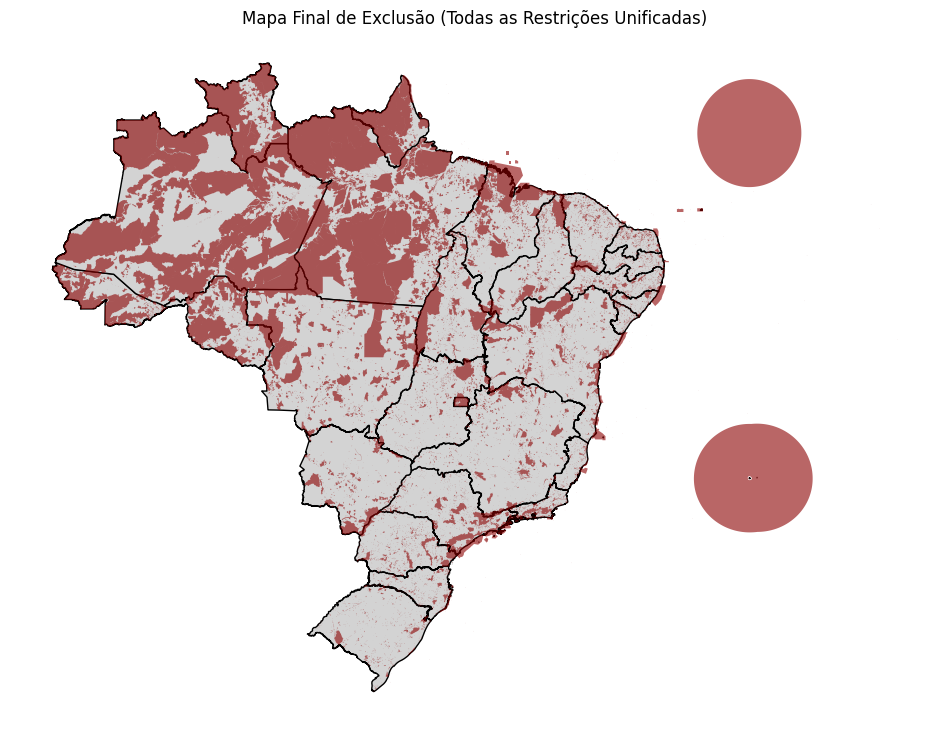

In [5]:
print("\nGerando mapa consolidado final das áreas de restrição...")
fig, ax = plt.subplots(figsize=(12, 12))

states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")

mascara_gdf.plot(ax=ax, color="darkred", alpha=0.6)

ax.set_title("Mapa Final de Exclusão (Todas as Restrições Unificadas)")
ax.set_axis_off()
plt.show()

## Inspeção da máscra com informação de tipo

In [6]:
print("\n--- Análise da Camada com tipos ---")
print(f"CRS: {super_camada_gdf.crs}")
print(f"Total de polígonos de restrição: {len(super_camada_gdf)}")

print("\nContagem de polígonos por origem:")
print(super_camada_gdf["origem"].value_counts())


--- Análise da Camada com tipos ---
CRS: EPSG:4674
Total de polígonos de restrição: 42468

Contagem de polígonos por origem:
origem
Sitio Arqueologico        30056
Assentamento Rural         8220
Unidade de Conservacao     3122
Terra Indigena              638
Territorio Quilombola       432
Name: count, dtype: int64


## Mapa de Restrição com informação de tipo


Gerando mapa da Camada com informação de tipo...


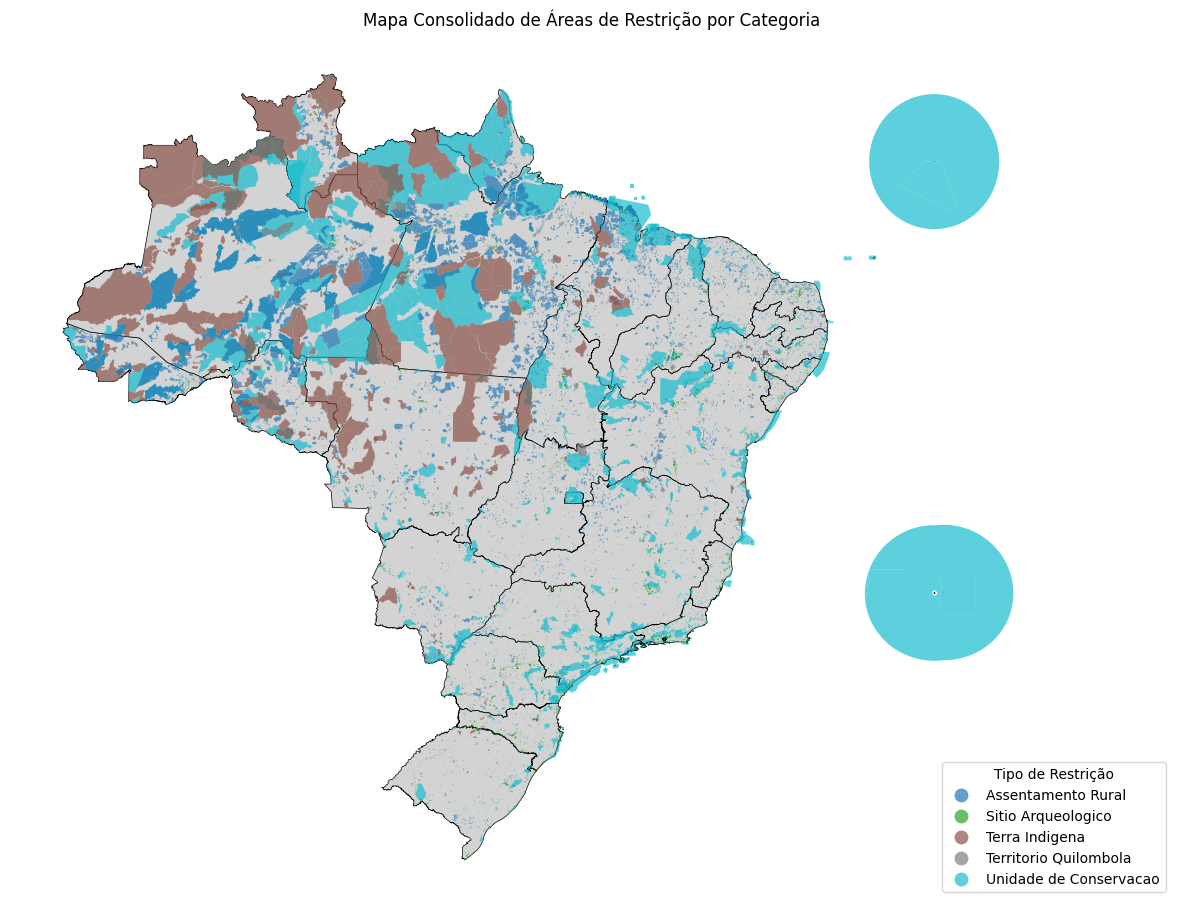

In [7]:
print("\nGerando mapa da Camada com informação de tipo...")
fig, ax = plt.subplots(figsize=(15, 15))

states_gdf.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5)

super_camada_gdf.plot(
    ax=ax,
    column="origem",
    categorical=True,
    legend=True,
    alpha=0.7,
    legend_kwds={"title": "Tipo de Restrição", "loc": "lower right"},
)

ax.set_title("Mapa Consolidado de Áreas de Restrição por Categoria")
ax.set_axis_off()
plt.show()